<a href="https://colab.research.google.com/github/raditya24ti/KELOMPOK5_PROSTAD_2TID/blob/main/kel5_prostat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Library berhasil di-import!")

Library berhasil di-import!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving online_retail_II.csv to online_retail_II.csv


In [ ]:
df = pd.read_csv('online_retail_II.csv')

print("Dataset berhasil dibaca!")

Dataset berhasil dibaca!


In [ ]:
print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

Jumlah baris : 1067371
Jumlah kolom : 8


In [ ]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [ ]:
df.dtypes

,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
Price,float64
Customer ID,float64
Country,object


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df['InvoiceDate'].dtype)

datetime64[ns]


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing': df.isnull().sum(),
    'Percentage': missing_percentage
})

missing_table

,Missing,Percentage
Invoice,0,0.000000
StockCode,0,0.000000
Description,4382,0.410541
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Customer ID,243007,22.766873
Country,0,0.000000


In [ ]:
duplicate_count = df.duplicated().sum()

print("Jumlah data duplikat:", duplicate_count)

Jumlah data duplikat: 34335


In [ ]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


In [ ]:
negative_quantity = (df['Quantity'] < 0).sum()

print("Jumlah transaksi dengan Quantity negatif:", negative_quantity)

Jumlah transaksi dengan Quantity negatif: 22950


In [ ]:
df[df['Quantity'] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [ ]:
cancelled = df['Invoice'].astype(str).str.startswith('C')

print("Jumlah baris dengan invoice cancellation:", cancelled.sum())

Jumlah baris dengan invoice cancellation: 19494


In [ ]:
df[cancelled].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [ ]:
print("Price = 0 :", (df['Price'] == 0).sum())
print("Price < 0 :", (df['Price'] < 0).sum())

Price = 0 : 6202
Price < 0 : 5


In [ ]:
df[df['Price'] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [ ]:
df['Revenue'] = df['Quantity'] * df['Price']

df[['Quantity', 'Price', 'Revenue']].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [ ]:
total_revenue = df['Revenue'].sum()

print(f"Total revenue data mentah: {total_revenue:,.2f}")

Total revenue data mentah: 19,287,250.57


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Tipe data InvoiceDate:", df['InvoiceDate'].dtype)

Tipe data InvoiceDate: datetime64[ns]


In [ ]:
negative_quantity = (df['Quantity'] < 0).sum()

print("Jumlah transaksi dengan Quantity negatif:", negative_quantity)

Jumlah transaksi dengan Quantity negatif: 22950


In [ ]:
df[df['Quantity'] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,-35.40
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,-9.90
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,-17.00
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,-12.60
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,-35.40
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia,-15.00
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia,-15.00
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia,-20.40
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,-35.40
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom,-12.75


In [ ]:
df[df['Quantity'] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,-35.40
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia,-9.90
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia,-17.00
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia,-12.60
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,-35.40
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia,-15.00
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia,-15.00
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia,-20.40
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia,-35.40
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom,-12.75


In [ ]:
df_clean = df.copy()

df_clean = df_clean[df_clean['Quantity'] > 0].copy()

print("Jumlah baris data bersih:", len(df_clean))
print("Jumlah Quantity negatif:", (df_clean['Quantity'] < 0).sum())

Jumlah baris data bersih: 1044421
Jumlah Quantity negatif: 0


In [ ]:
print("Price = 0:", (df_clean['Price'] == 0).sum())
print("Price < 0:", (df_clean['Price'] < 0).sum())

Price = 0: 2745
Price < 0: 5


In [ ]:
df_clean[df_clean['Price'] == 0][
    ['Invoice', 'StockCode', 'Description', 'Quantity',
     'InvoiceDate', 'Price', 'Customer ID', 'Country']
].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
5904,489861,DOT,DOTCOM POSTAGE,1,2009-12-02 14:50:00,0.0,NaN,United Kingdom
6378,489882,35751C,NaN,12,2009-12-02 16:22:00,0.0,NaN,United Kingdom
6555,489898,79323G,NaN,954,2009-12-03 09:40:00,0.0,NaN,United Kingdom
6581,489903,21166,NaN,48,2009-12-03 09:57:00,0.0,NaN,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
7204,490015,21982,NaN,467,2009-12-03 12:29:00,0.0,NaN,United Kingdom
9249,490123,84508B,NaN,184,2009-12-03 18:08:00,0.0,NaN,United Kingdom


In [ ]:
df_clean = df_clean[df_clean['Price'] > 0].copy()

print("Jumlah baris setelah membersihkan Price:", len(df_clean))
print("Price <= 0:", (df_clean['Price'] <= 0).sum())

Jumlah baris setelah membersihkan Price: 1041671
Price <= 0: 0


In [ ]:
print("Quantity <= 0:", (df_clean['Quantity'] <= 0).sum())
print("Price <= 0:", (df_clean['Price'] <= 0).sum())

Quantity <= 0: 0
Price <= 0: 0


In [ ]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['Price']

df_clean[['Quantity', 'Price', 'Revenue']].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [ ]:
print("Total Revenue:", f"{df_clean['Revenue'].sum():,.2f}")
print("Minimum Revenue:", f"{df_clean['Revenue'].min():,.2f}")
print("Maximum Revenue:", f"{df_clean['Revenue'].max():,.2f}")

Total Revenue: 20,972,968.14
Minimum Revenue: 0.00
Maximum Revenue: 168,469.60


In [ ]:
zero_revenue = (df_clean['Revenue'] == 0).sum()

print("Jumlah Revenue = 0:", zero_revenue)

Jumlah Revenue = 0: 0


In [ ]:
df_clean[df_clean['Revenue'] == 0][
    ['Quantity', 'Price', 'Revenue', 'Description']
].head(10)

,Quantity,Price,Revenue,Description


In [ ]:
duplicate_clean = df_clean.duplicated().sum()

print("Jumlah duplicate setelah cleaning:", duplicate_clean)

Jumlah duplicate setelah cleaning: 33757


In [ ]:
df_clean = df_clean.drop_duplicates().copy()

print("Jumlah baris setelah menghapus duplicate:", len(df_clean))
print("Jumlah duplicate sekarang:", df_clean.duplicated().sum())

Jumlah baris setelah menghapus duplicate: 1007914
Jumlah duplicate sekarang: 0


In [ ]:
missing_customer = df_clean['Customer ID'].isna().sum()
total_data = len(df_clean)

print("Customer ID kosong:", missing_customer)
print("Total data:", total_data)
print("Persentase Customer ID kosong:",
      round(missing_customer / total_data * 100, 2), "%")

Customer ID kosong: 228489
Total data: 1007914
Persentase Customer ID kosong: 22.67 %


In [ ]:
df_clean[['Quantity', 'Price', 'Revenue']].describe()

,Quantity,Price,Revenue
count,1.007914e+06,1.007914e+06,1.007914e+06
mean,1.111717e+01,4.074618e+00,2.031585e+01
std,1.284700e+02,5.043177e+01,2.057160e+02
min,1.000000e+00,1.000000e-03,1.000000e-03
25%,1.000000e+00,1.250000e+00,4.130000e+00
50%,4.000000e+00,2.100000e+00,1.008000e+01
75%,1.200000e+01,4.130000e+00,1.770000e+01
max,8.099500e+04,2.511109e+04,1.684696e+05


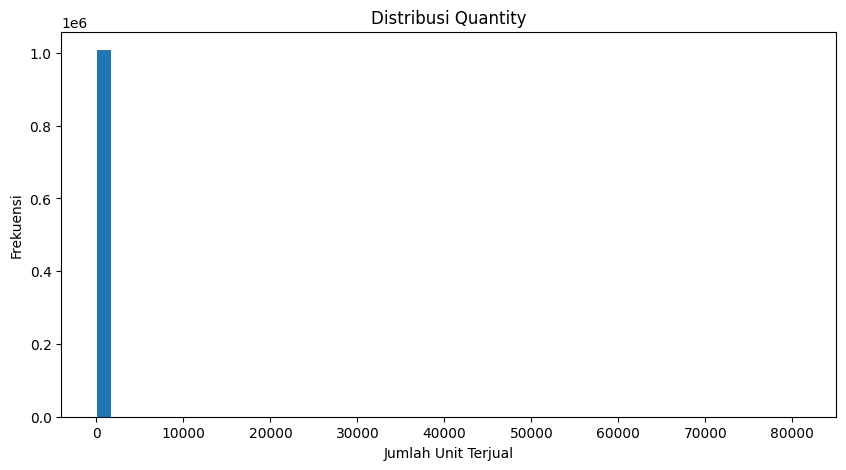

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(df_clean['Quantity'], bins=50)

plt.title('Distribusi Quantity')
plt.xlabel('Jumlah Unit Terjual')
plt.ylabel('Frekuensi')

plt.show()

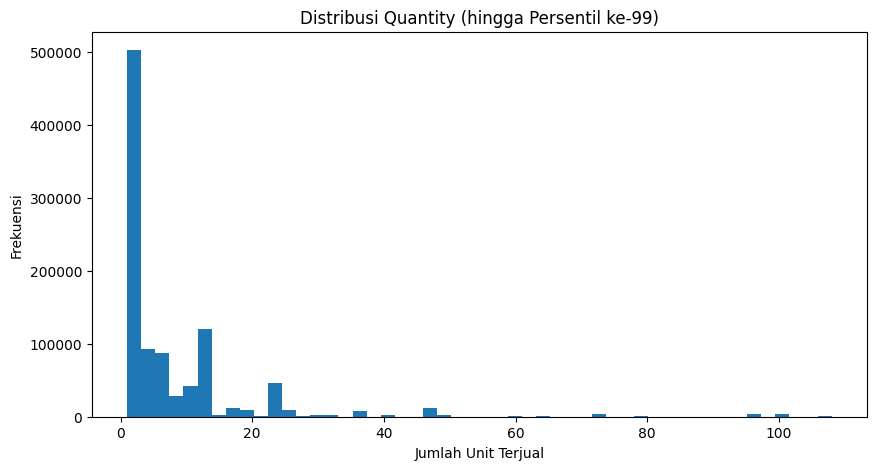

Persentil ke-99 Quantity: 108.0


In [ ]:
q99 = df_clean['Quantity'].quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    df_clean[df_clean['Quantity'] <= q99]['Quantity'],
    bins=50
)

plt.title('Distribusi Quantity (hingga Persentil ke-99)')
plt.xlabel('Jumlah Unit Terjual')
plt.ylabel('Frekuensi')

plt.show()

print("Persentil ke-99 Quantity:", q99)

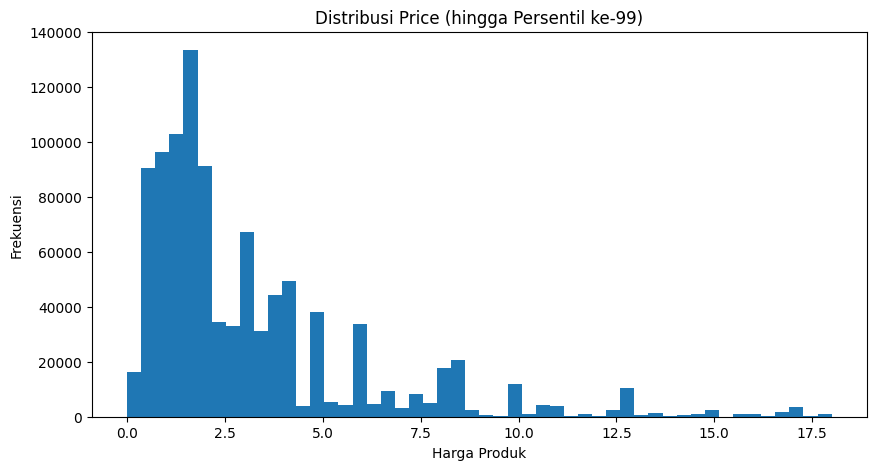

Persentil ke-99 Price: 18.0


In [ ]:
p99 = df_clean['Price'].quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    df_clean[df_clean['Price'] <= p99]['Price'],
    bins=50
)

plt.title('Distribusi Price (hingga Persentil ke-99)')
plt.xlabel('Harga Produk')
plt.ylabel('Frekuensi')

plt.show()

print("Persentil ke-99 Price:", p99)

In [ ]:
print("Persentil ke-99 Price:", p99)

Persentil ke-99 Price: 18.0


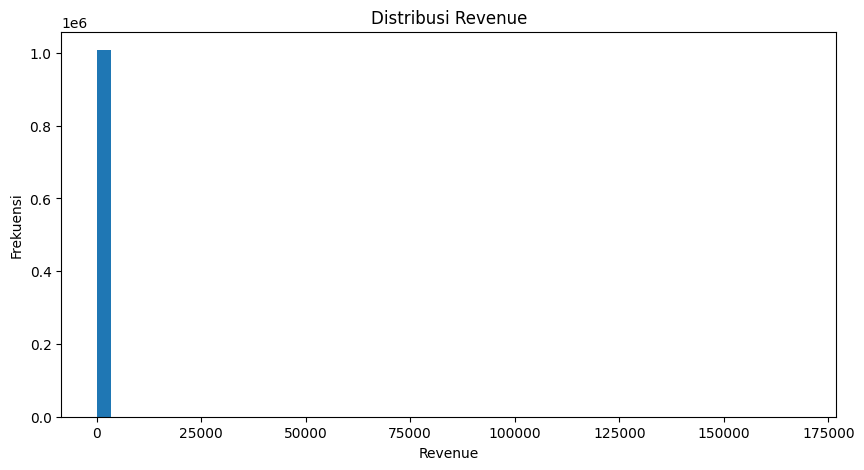

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(df_clean['Revenue'], bins=50)

plt.title('Distribusi Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frekuensi')

plt.show()

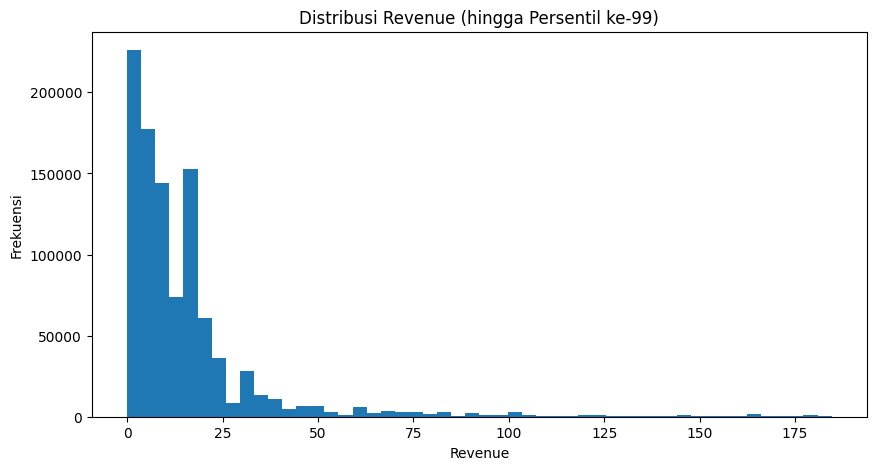

Persentil ke-99 Revenue: 184.66959999999963


In [ ]:
r99 = df_clean['Revenue'].quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    df_clean[df_clean['Revenue'] <= r99]['Revenue'],
    bins=50
)

plt.title('Distribusi Revenue (hingga Persentil ke-99)')
plt.xlabel('Revenue')
plt.ylabel('Frekuensi')

plt.show()

print("Persentil ke-99 Revenue:", r99)

In [ ]:
daily_transactions = (
    df_clean
    .groupby(df_clean['InvoiceDate'].dt.date)['Invoice']
    .nunique()
)

print("Jumlah hari:", len(daily_transactions))
print("\n5 hari pertama:")
print(daily_transactions.head())

Jumlah hari: 604

5 hari pertama:
InvoiceDate
2009-12-01    119
2009-12-02    115
2009-12-03    124
2009-12-04     89
2009-12-05     30
Name: Invoice, dtype: int64


In [ ]:
lambda_poisson = daily_transactions.mean()

print("Lambda (rata-rata transaksi per hari):", lambda_poisson)
print("Standar deviasi:", daily_transactions.std())
print("Minimum transaksi per hari:", daily_transactions.min())
print("Maksimum transaksi per hari:", daily_transactions.max())

Lambda (rata-rata transaksi per hari): 66.3543046357616
Standar deviasi: 24.777824663155048
Minimum transaksi per hari: 11
Maksimum transaksi per hari: 153


In [ ]:
mean_daily = daily_transactions.mean()
variance_daily = daily_transactions.var()

print("Mean transaksi harian:", mean_daily)
print("Variance transaksi harian:", variance_daily)
print("Variance / Mean:", variance_daily / mean_daily)

Mean transaksi harian: 66.3543046357616
Variance transaksi harian: 613.9405950380547
Variance / Mean: 9.25246068673549


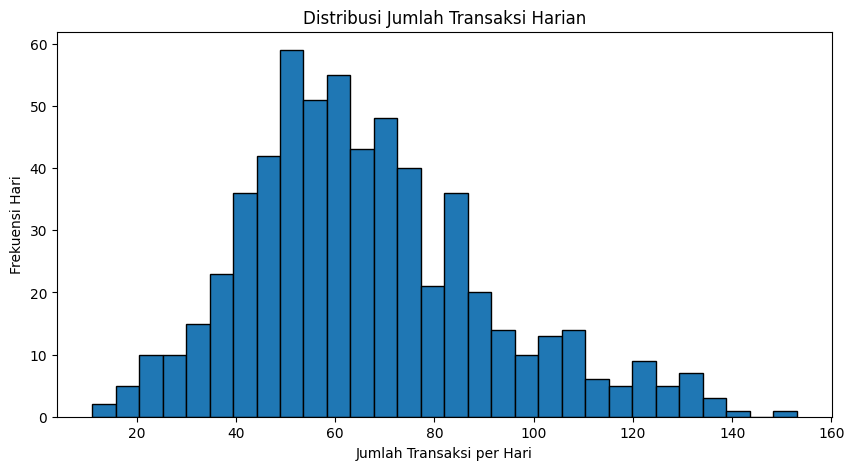

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    daily_transactions,
    bins=30,
    edgecolor='black'
)

plt.title('Distribusi Jumlah Transaksi Harian')
plt.xlabel('Jumlah Transaksi per Hari')
plt.ylabel('Frekuensi Hari')

plt.show()

In [ ]:
from scipy.stats import poisson

# Kelompokkan jumlah transaksi harian
bins = [
    (-float('inf'), 49),
    (50, 59),
    (60, 69),
    (70, 79),
    (80, float('inf'))
]

observed = []
expected = []

for lower, upper in bins:
    if lower == -float('inf'):
        obs = (daily_transactions <= upper).sum()
        exp = poisson.cdf(upper, lambda_poisson) * len(daily_transactions)
    elif upper == float('inf'):
        obs = (daily_transactions >= lower).sum()
        exp = (1 - poisson.cdf(lower - 1, lambda_poisson)) * len(daily_transactions)
    else:
        obs = ((daily_transactions >= lower) & (daily_transactions <= upper)).sum()
        exp = (
            poisson.cdf(upper, lambda_poisson)
            - poisson.cdf(lower - 1, lambda_poisson)
        ) * len(daily_transactions)

    observed.append(obs)
    expected.append(exp)

print("Observed:", observed)
print("Expected:", expected)

Observed: [np.int64(155), np.int64(110), np.int64(108), np.int64(77), np.int64(154)]
Expected: [np.float64(9.625506804081807), np.float64(112.1734764141122), np.float64(274.8575191830724), np.float64(173.1829146572937), np.float64(34.160582941439905)]


In [ ]:
from scipy.stats import chisquare

# Uji Chi-Square Goodness-of-Fit
chi2_stat, p_value = chisquare(
    f_obs=observed,
    f_exp=expected,
    ddof=1
)

print("Chi-Square Statistic:", chi2_stat)
print("p-value:", p_value)

Chi-Square Statistic: 2770.7635664669624
p-value: 0.0


In [ ]:
country_summary = (
    df_clean
    .groupby('Country')['Revenue']
    .agg(['count', 'mean', 'std'])
    .sort_values('count', ascending=False)
)

print(country_summary)

                       count        mean         std
Country                                             
United Kingdom        926039   18.801119  212.690077
EIRE                   17154   38.403131   93.995229
Germany                16432   25.865367   34.921920
France                 13639   25.695146   72.465844
Netherlands             5085  108.955377  150.966652
Spain                   3662   29.582875   83.283123
Switzerland             3122   32.250349   41.446427
Belgium                 3055   21.403542   31.881821
Portugal                2470   22.786854   45.885921
Australia               1789   94.624628  142.385935
Channel Islands         1551   28.770683   43.882390
Italy                   1442   22.266415   21.898852
Sweden                  1336   68.764835  101.551908
Norway                  1289   43.694725  275.878952
Cyprus                  1136   21.874956   29.475578
Finland                 1032   28.997616   42.887136
Austria                  922   25.610640   33.

In [ ]:
# Menggabungkan revenue menjadi nilai per transaksi (Invoice)
invoice_revenue = (
    df_clean
    .groupby(['Country', 'Invoice'], as_index=False)['Revenue']
    .sum()
)

# Ringkasan jumlah transaksi dan revenue per negara
country_invoice_summary = (
    invoice_revenue
    .groupby('Country')['Revenue']
    .agg(['count', 'mean', 'std'])
    .sort_values('count', ascending=False)
)

print(country_invoice_summary)

                      count         mean          std
Country                                              
United Kingdom        36536   476.531905  1439.784434
Germany                 789   538.681510   596.885626
EIRE                    626  1052.343946  2350.665148
France                  622   563.434228   815.659393
Netherlands             228  2429.991623  3947.078009
Spain                   154   703.457727   864.404090
Belgium                 149   438.844430   351.975243
Sweden                  105   874.950667  1066.680791
Portugal                 95   592.458211   522.125536
Australia                95  1781.931158  4547.171630
Switzerland              93  1082.640753  1720.869985
Italy                    65   493.971846   394.238712
Finland                  57   525.009474   431.975464
Channel Islands          55   811.333273   495.861471
Norway                   45  1251.611111  1589.830169
Austria                  45   524.733556   403.733829
Denmark                  43 

In [ ]:
# Pilih negara dengan minimal 10 transaksi
country_counts = invoice_revenue['Country'].value_counts()

valid_countries = country_counts[country_counts >= 10].index

invoice_revenue_test = invoice_revenue[
    invoice_revenue['Country'].isin(valid_countries)
].copy()

print("Jumlah negara yang dianalisis:", invoice_revenue_test['Country'].nunique())
print("Jumlah transaksi yang dianalisis:", len(invoice_revenue_test))

print("\nJumlah transaksi per negara:")
print(invoice_revenue_test['Country'].value_counts())

Jumlah negara yang dianalisis: 28
Jumlah transaksi yang dianalisis: 40024

Jumlah transaksi per negara:
Country
United Kingdom          36536
Germany                   789
EIRE                      626
France                    622
Netherlands               228
Spain                     154
Belgium                   149
Sweden                    105
Australia                  95
Portugal                   95
Switzerland                93
Italy                      65
Finland                    57
Channel Islands            55
Austria                    45
Norway                     45
Denmark                    43
Cyprus                     37
Japan                      33
Poland                     28
Unspecified                24
USA                        20
Greece                     18
United Arab Emirates       16
Hong Kong                  15
Singapore                  11
Bahrain                    10
Israel                     10
Name: count, dtype: int64


In [ ]:
from scipy.stats import kruskal

# Membuat kelompok revenue per negara
groups = [
    group['Revenue'].values
    for country, group in invoice_revenue_test.groupby('Country')
]

# Uji Kruskal-Wallis
h_stat, p_value = kruskal(*groups)

print("Kruskal-Wallis H:", h_stat)
print("p-value:", p_value)

Kruskal-Wallis H: 944.6371884827829
p-value: 1.2052247853356967e-181


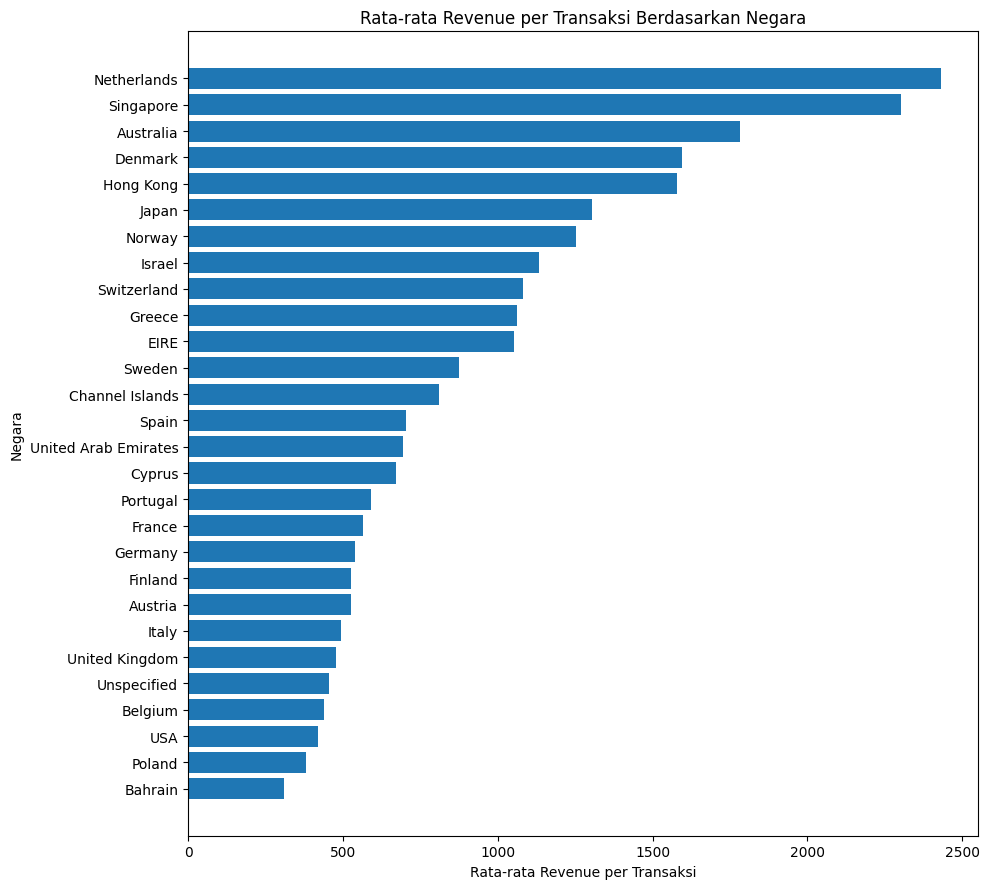

In [ ]:
import matplotlib.pyplot as plt

# Hitung rata-rata revenue per transaksi tiap negara
mean_revenue_country = (
    invoice_revenue_test
    .groupby('Country')['Revenue']
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 9))
plt.barh(
    mean_revenue_country.index,
    mean_revenue_country.values
)

plt.title('Rata-rata Revenue per Transaksi Berdasarkan Negara')
plt.xlabel('Rata-rata Revenue per Transaksi')
plt.ylabel('Negara')
plt.tight_layout()
plt.show()

In [ ]:
# Simpan data hasil cleaning ke CSV
df_clean.to_csv('online_retail_II_clean.csv', index=False)

# Download file
from google.colab import files
files.download('online_retail_II_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>